In [25]:
import pandas as pd

df= pd.read_csv("ai_student_impact_dataset.csv")

info=df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

ossevare corr votazione, incremento, skill retention e burnout
Major_Category -> più colonne?
Year_of_Study -> diventa int 
Primary_Use_Case -> più colonne?
Prompt_Engineering_Skill -> int
Institutional_Policy -> int


In [26]:
df["GPA_increment"] = df["Post_Semester_GPA"]- df["Pre_Semester_GPA"]

In [27]:
df.value_counts(df["Burnout_Risk_Level"])
trad={"Low":1,"Medium":2,"High":3}
df["Burnout_Risk_Level"]=df["Burnout_Risk_Level"].map(trad)

In [28]:
df[["Burnout_Risk_Level","GPA_increment","Post_Semester_GPA","Skill_Retention_Score"]].corr()

,Burnout_Risk_Level,GPA_increment,Post_Semester_GPA,Skill_Retention_Score
Burnout_Risk_Level,1.000000,-0.006818,-0.095543,-0.058140
GPA_increment,-0.006818,1.000000,0.277146,0.195833
Post_Semester_GPA,-0.095543,0.277146,1.000000,0.169616
Skill_Retention_Score,-0.058140,0.195833,0.169616,1.000000


togliamo ora il target e info su Burnout e Skill Retention

In [29]:
y= df["GPA_increment"].copy()
df.drop(columns=["Burnout_Risk_Level","Skill_Retention_Score"], inplace=True)

In [30]:
df.drop(columns="Student_ID",inplace=True)

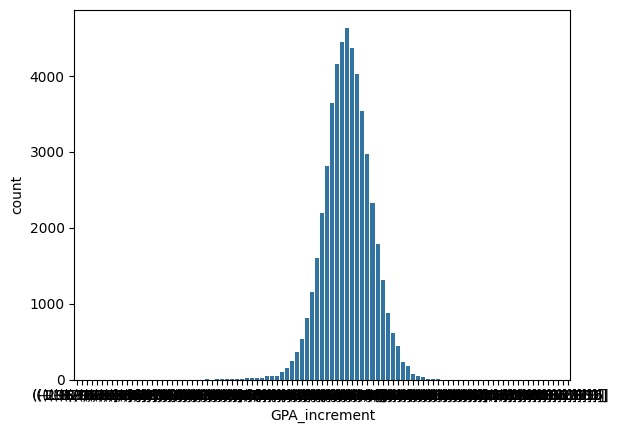

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

gruppi = pd.cut(y, np.linspace(-2,2,100))

sns.countplot(x=gruppi)
plt.show()


In [32]:
df.value_counts(df["Major_Category"])

Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

fare modelli diversi per percorsi diversi?

In [33]:
trad={
"Junior": 3 ,
"Freshman" : 1,
"Senior"  : 4, 
"Sophomore"  : 2,
"Graduate" : 5,
}

df["Year_of_Study"]=df["Year_of_Study"].map(trad)

print(df["Year_of_Study"].unique())

[4 3 1 2 5]


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Major_Category              50000 non-null  str    
 1   Year_of_Study               50000 non-null  int64  
 2   Pre_Semester_GPA            50000 non-null  float64
 3   Weekly_GenAI_Hours          50000 non-null  float64
 4   Primary_Use_Case            50000 non-null  str    
 5   Prompt_Engineering_Skill    50000 non-null  str    
 6   Tool_Diversity              50000 non-null  int64  
 7   Paid_Subscription           50000 non-null  bool   
 8   Traditional_Study_Hours     50000 non-null  float64
 9   Perceived_AI_Dependency     50000 non-null  int64  
 10  Institutional_Policy        50000 non-null  str    
 11  Anxiety_Level_During_Exams  50000 non-null  int64  
 12  Post_Semester_GPA           50000 non-null  float64
 13  GPA_increment               50000 non-null

In [35]:
for corso in df["Primary_Use_Case"].unique():
    df["is_"+corso]= df["Primary_Use_Case"]==corso

df.drop(columns="Primary_Use_Case",inplace=True)

In [36]:
df.value_counts(df["Prompt_Engineering_Skill"])

Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64

In [37]:
trad={
"Beginner": 1 ,
"Intermediate" : 2,
"Advanced"  : 3, 
}

df["Prompt_Engineering_Skill"]=df["Prompt_Engineering_Skill"].map(trad)

print(df["Prompt_Engineering_Skill"].unique())

[1 3 2]


In [38]:

df.value_counts(df["Institutional_Policy"])

Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64

In [39]:
for corso in df["Institutional_Policy"].unique():
    df["is_"+corso]= df["Institutional_Policy"]==corso

df.drop(columns="Institutional_Policy",inplace=True)

primo approccio mantenere categorie tutte assieme nello stesso dataset ma in colonne diverse e vediamo (poi dopo proviamo a dividere dataset per fare 5 modelli diversi)

In [40]:
df_by_category = df.copy() #salvo una copia del dataset per poi usarlo dopo per creare modelli separati

In [41]:
for corso in df["Major_Category"].unique():
    df["major_is_"+corso]= df["Major_Category"]==corso

df.drop(columns="Major_Category",inplace=True)

In [42]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
df.drop(columns="GPA_increment",inplace=True,errors=True)
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42)

modello baseline

In [43]:
from xgboost import XGBRegressor

rf_model = XGBRegressor(
    n_estimators=100,
    random_state=42
)


rf_model.fit(X_train, y_train) 

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [44]:
predictions = rf_model.predict(X_test)

print(mean_absolute_error(y_test, predictions))

print(r2_score(y_test, predictions))

0.013894464762454643
0.988228633127005


In [45]:
# un dataframe per ogni categoria
df_dict={
    k:df_by_category[df_by_category["Major_Category"] == k]  for k in df_by_category["Major_Category"].unique()
}


In [46]:
for d in df_dict.values():
    d.drop(columns=["Major_Category"], inplace=True)
    d.drop(columns=["GPA_increment"], inplace=True)
d.info()


<class 'pandas.DataFrame'>
Index: 5933 entries, 7 to 49999
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year_of_Study                 5933 non-null   int64  
 1   Pre_Semester_GPA              5933 non-null   float64
 2   Weekly_GenAI_Hours            5933 non-null   float64
 3   Prompt_Engineering_Skill      5933 non-null   int64  
 4   Tool_Diversity                5933 non-null   int64  
 5   Paid_Subscription             5933 non-null   bool   
 6   Traditional_Study_Hours       5933 non-null   float64
 7   Perceived_AI_Dependency       5933 non-null   int64  
 8   Anxiety_Level_During_Exams    5933 non-null   int64  
 9   Post_Semester_GPA             5933 non-null   float64
 10  is_Copywriting/Drafting       5933 non-null   bool   
 11  is_Ideation                   5933 non-null   bool   
 12  is_Summarizing_Reading        5933 non-null   bool   
 13  is_Debugging/Troub

In [47]:
model_params_major_dict={}

import optuna

def objective(trial):

    data= df_dict[corso]
    y=data["Post_Semester_GPA"]
    X=data.drop(columns='Post_Semester_GPA')

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'mae',
        'tree_method': 'hist',
        'enable_categorical':True,
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0,
        'bootstrap_type': "Bayesian",
        
       
        'n_estimators': trial.suggest_int('n_estimators', 50, 250),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3,18),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True)
    }

    if params["bootstrap_type"] == "Bayesian":
        params["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0, 10)
    elif params["bootstrap_type"] == "Bernoulli":
        params["subsample"] = trial.suggest_float("subsample", 0.1, 1)

    model = XGBRegressor(**params)

    model.fit(X_train, y_train,verbose=1)

    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    return mae


[I 2026-06-04 17:14:11,229] A new study created in memory with name: no-name-69d10743-6225-4d5e-87ec-d6e76f718756
[I 2026-06-04 17:14:11,303] Trial 0 finished with value: 0.1153149634543033 and parameters: {'n_estimators': 166, 'learning_rate': 0.08069330182268673, 'max_depth': 4, 'subsample': 0.892860487623399, 'colsample_bytree': 0.615581814649196, 'reg_alpha': 0.6048328194521747, 'bagging_temperature': 3.8184078793269114}. Best is trial 0 with value: 0.1153149634543033.


major Humanities


[I 2026-06-04 17:14:11,712] Trial 1 finished with value: 0.12287367858524141 and parameters: {'n_estimators': 189, 'learning_rate': 0.07640559192654721, 'max_depth': 16, 'subsample': 0.734308864624784, 'colsample_bytree': 0.9241157479179442, 'reg_alpha': 0.6357241409843483, 'bagging_temperature': 9.079676584913818}. Best is trial 0 with value: 0.1153149634543033.
[I 2026-06-04 17:14:12,314] Trial 2 finished with value: 0.13514612046976934 and parameters: {'n_estimators': 177, 'learning_rate': 0.0736309350049665, 'max_depth': 13, 'subsample': 0.8218612215442249, 'colsample_bytree': 0.7495438066016501, 'reg_alpha': 0.021754455450317765, 'bagging_temperature': 0.028786356654030287}. Best is trial 0 with value: 0.1153149634543033.
[I 2026-06-04 17:14:12,384] Trial 3 finished with value: 0.11593010915381244 and parameters: {'n_estimators': 213, 'learning_rate': 0.044660442016303696, 'max_depth': 4, 'subsample': 0.7028277968412329, 'colsample_bytree': 0.7398434042464829, 'reg_alpha': 0.00224

Number of finished trials: 100
Best trial:
  Value: 0.11509604250472327
  Params: 
    n_estimators: 119
    learning_rate: 0.0906790866392615
    max_depth: 4
    subsample: 0.9271835772068934
    colsample_bytree: 0.9999639693043277
    reg_alpha: 0.2482377937946708
    bagging_temperature: 3.7728597488723916
business mae: 0.11578529812133928
business r2: 0.9146705345615765


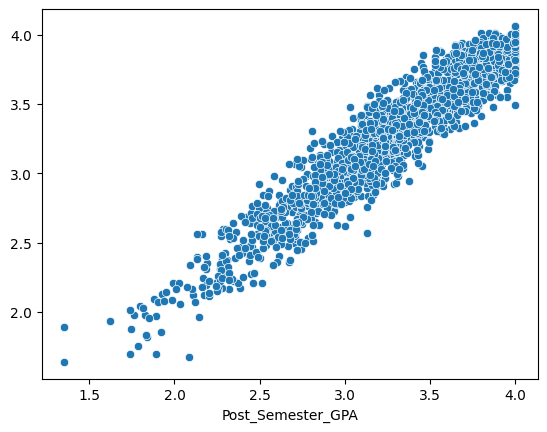

[I 2026-06-04 17:14:21,834] A new study created in memory with name: no-name-267e812d-c95d-4887-a05d-fb78e18d9a70


major Medical


[I 2026-06-04 17:14:22,428] Trial 0 finished with value: 0.14463620074001357 and parameters: {'n_estimators': 186, 'learning_rate': 0.07436556967086706, 'max_depth': 18, 'subsample': 0.621634621933728, 'colsample_bytree': 0.7331715402344535, 'reg_alpha': 0.03089654865781481, 'bagging_temperature': 3.1071545385668498}. Best is trial 0 with value: 0.14463620074001357.
[I 2026-06-04 17:14:22,511] Trial 1 finished with value: 0.13808857014738482 and parameters: {'n_estimators': 185, 'learning_rate': 0.020429858544367314, 'max_depth': 4, 'subsample': 0.6527170384496765, 'colsample_bytree': 0.6079293294512401, 'reg_alpha': 4.271347504590382, 'bagging_temperature': 6.259924549564787}. Best is trial 1 with value: 0.13808857014738482.
[I 2026-06-04 17:14:22,739] Trial 2 finished with value: 0.35237782472445645 and parameters: {'n_estimators': 73, 'learning_rate': 0.0037147093681275606, 'max_depth': 18, 'subsample': 0.6805544647494786, 'colsample_bytree': 0.7568265855463941, 'reg_alpha': 0.16097

Number of finished trials: 100
Best trial:
  Value: 0.1153338869302361
  Params: 
    n_estimators: 171
    learning_rate: 0.07476658526215173
    max_depth: 3
    subsample: 0.7095099566816745
    colsample_bytree: 0.9733769872313518
    reg_alpha: 0.04222128682044697
    bagging_temperature: 1.6843804127169466
business mae: 0.11566294692401535
business r2: 0.9146079372053848


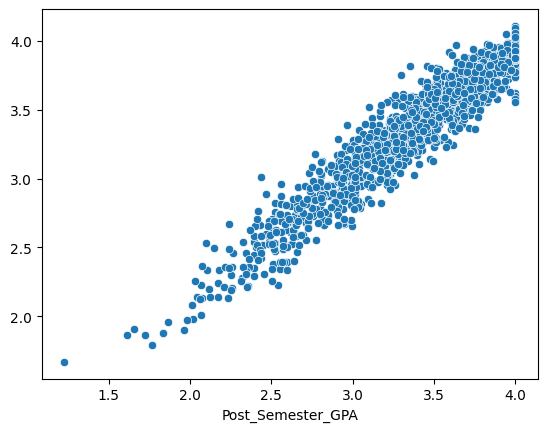

[I 2026-06-04 17:14:30,187] A new study created in memory with name: no-name-2b466c80-eeba-4e4b-9548-5bc6f510884f


major Business


[I 2026-06-04 17:14:30,507] Trial 0 finished with value: 0.12374094737393623 and parameters: {'n_estimators': 243, 'learning_rate': 0.054720433619739106, 'max_depth': 10, 'subsample': 0.861592702832595, 'colsample_bytree': 0.7290713874471356, 'reg_alpha': 0.28172889940971757, 'bagging_temperature': 6.774166110681748}. Best is trial 0 with value: 0.12374094737393623.
[I 2026-06-04 17:14:31,729] Trial 1 finished with value: 0.25609737709340485 and parameters: {'n_estimators': 171, 'learning_rate': 0.004849543157938184, 'max_depth': 18, 'subsample': 0.7302818822172901, 'colsample_bytree': 0.7435382087330216, 'reg_alpha': 0.002297380273842333, 'bagging_temperature': 1.34100233396246}. Best is trial 0 with value: 0.12374094737393623.
[I 2026-06-04 17:14:32,080] Trial 2 finished with value: 0.16553972352710827 and parameters: {'n_estimators': 97, 'learning_rate': 0.020077901032592688, 'max_depth': 14, 'subsample': 0.682716393741337, 'colsample_bytree': 0.8011192445712957, 'reg_alpha': 0.0966

Number of finished trials: 100
Best trial:
  Value: 0.1150070740225973
  Params: 
    n_estimators: 191
    learning_rate: 0.175505842064024
    max_depth: 3
    subsample: 0.9679033091589418
    colsample_bytree: 0.9638468020701415
    reg_alpha: 2.6880922523497404
    bagging_temperature: 6.709012242732952
business mae: 0.11557653387387591
business r2: 0.9073250049607108


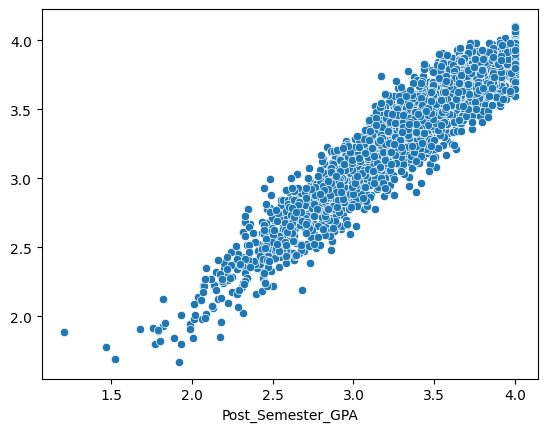

[I 2026-06-04 17:14:43,843] A new study created in memory with name: no-name-8bdef90c-1504-4195-beaf-d1d50f95d4ec


major STEM


[I 2026-06-04 17:14:43,968] Trial 0 finished with value: 0.1184869461626329 and parameters: {'n_estimators': 222, 'learning_rate': 0.028340544212000267, 'max_depth': 6, 'subsample': 0.7234670458782901, 'colsample_bytree': 0.686005428843856, 'reg_alpha': 0.023395835815321498, 'bagging_temperature': 9.182745551578833}. Best is trial 0 with value: 0.1184869461626329.
[I 2026-06-04 17:14:44,126] Trial 1 finished with value: 0.12076236006938128 and parameters: {'n_estimators': 239, 'learning_rate': 0.12653477499137583, 'max_depth': 7, 'subsample': 0.963606042469147, 'colsample_bytree': 0.9607154132645084, 'reg_alpha': 0.08971811509029937, 'bagging_temperature': 3.89535861799597}. Best is trial 0 with value: 0.1184869461626329.
[I 2026-06-04 17:14:44,247] Trial 2 finished with value: 0.12112125843327992 and parameters: {'n_estimators': 138, 'learning_rate': 0.10726994273712441, 'max_depth': 8, 'subsample': 0.8612978238501184, 'colsample_bytree': 0.7014732567066305, 'reg_alpha': 0.04055054946

Number of finished trials: 100
Best trial:
  Value: 0.11740923130623056
  Params: 
    n_estimators: 131
    learning_rate: 0.15079031605908463
    max_depth: 18
    subsample: 0.8484654854207752
    colsample_bytree: 0.7803804972534212
    reg_alpha: 5.03275796201564
    bagging_temperature: 7.901941548082606
business mae: 0.11812099799470281
business r2: 0.9044801657888698


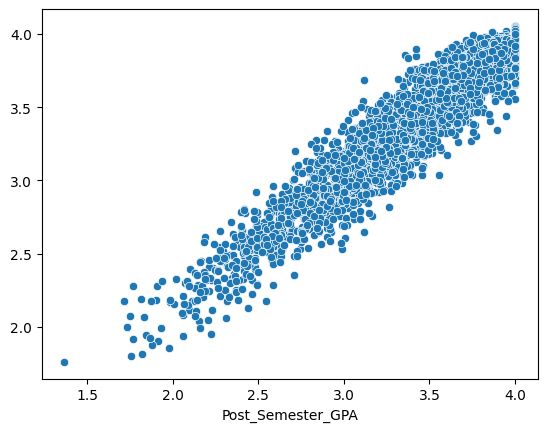

[I 2026-06-04 17:15:02,891] A new study created in memory with name: no-name-49c6480c-ced8-465d-9e1c-6d8e70449f45


major Arts


[I 2026-06-04 17:15:03,015] Trial 0 finished with value: 0.34656806869635387 and parameters: {'n_estimators': 131, 'learning_rate': 0.0022812603507418633, 'max_depth': 15, 'subsample': 0.6777814798985466, 'colsample_bytree': 0.747827800382143, 'reg_alpha': 1.8738239570110027, 'bagging_temperature': 4.19361549880949}. Best is trial 0 with value: 0.34656806869635387.
[I 2026-06-04 17:15:03,148] Trial 1 finished with value: 0.13132061966106284 and parameters: {'n_estimators': 109, 'learning_rate': 0.034511856018767356, 'max_depth': 10, 'subsample': 0.6398841324320279, 'colsample_bytree': 0.8265238166095534, 'reg_alpha': 0.20238022579648757, 'bagging_temperature': 6.390031944661072}. Best is trial 1 with value: 0.13132061966106284.
[I 2026-06-04 17:15:03,213] Trial 2 finished with value: 0.22129389716118647 and parameters: {'n_estimators': 177, 'learning_rate': 0.00793209032773568, 'max_depth': 6, 'subsample': 0.7492134871978777, 'colsample_bytree': 0.6825154874926116, 'reg_alpha': 9.97801

Number of finished trials: 100
Best trial:
  Value: 0.11800139479809883
  Params: 
    n_estimators: 223
    learning_rate: 0.10878603338844105
    max_depth: 4
    subsample: 0.9688545774276022
    colsample_bytree: 0.96173046523082
    reg_alpha: 2.53428657875115
    bagging_temperature: 5.482953824704802
business mae: 0.1187320501051134
business r2: 0.9127628720225314


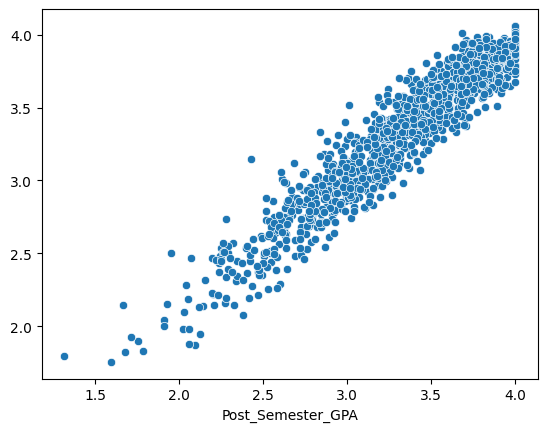

In [ ]:
best_model_major_dict={}
import seaborn as sns
for corso in df_dict.keys():
    
    print(f"major {corso}")
    c=corso

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=100, timeout=600)

    print("Number of finished trials: {}".format(len(study.trials)))

    print("Best trial:")
    trial = study.best_trial

    print("  Value: {}".format(trial.value))

    print("  Params: ")
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))
    
    optimal_params = study.best_trial.params
    model_params_major_dict[corso]=optimal_params
    model=XGBRegressor(**optimal_params)
    data= df_dict[corso]
    y=data["Post_Semester_GPA"]
    X=data.drop(columns='Post_Semester_GPA')

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train,y_train)
    preds = model.predict(X_test)

    print("business mae:", mean_absolute_error(y_test, preds))
    print("business r2:", r2_score(y_test, preds))
    best_model_major_dict[corso]=model







    


c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:46:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:46:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:46:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:46:49]

Humanities mae: 0.11578529812133928
Humanities r2: 0.9146705345615765
Medical mae: 0.11566294692401535
Medical r2: 0.9146079372053848
Business mae: 0.11557653387387591
Business r2: 0.9073250049607108
STEM mae: 0.11812099799470281
STEM r2: 0.9044801657888698
Arts mae: 0.1187320501051134
Arts r2: 0.9127628720225314


c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:46:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


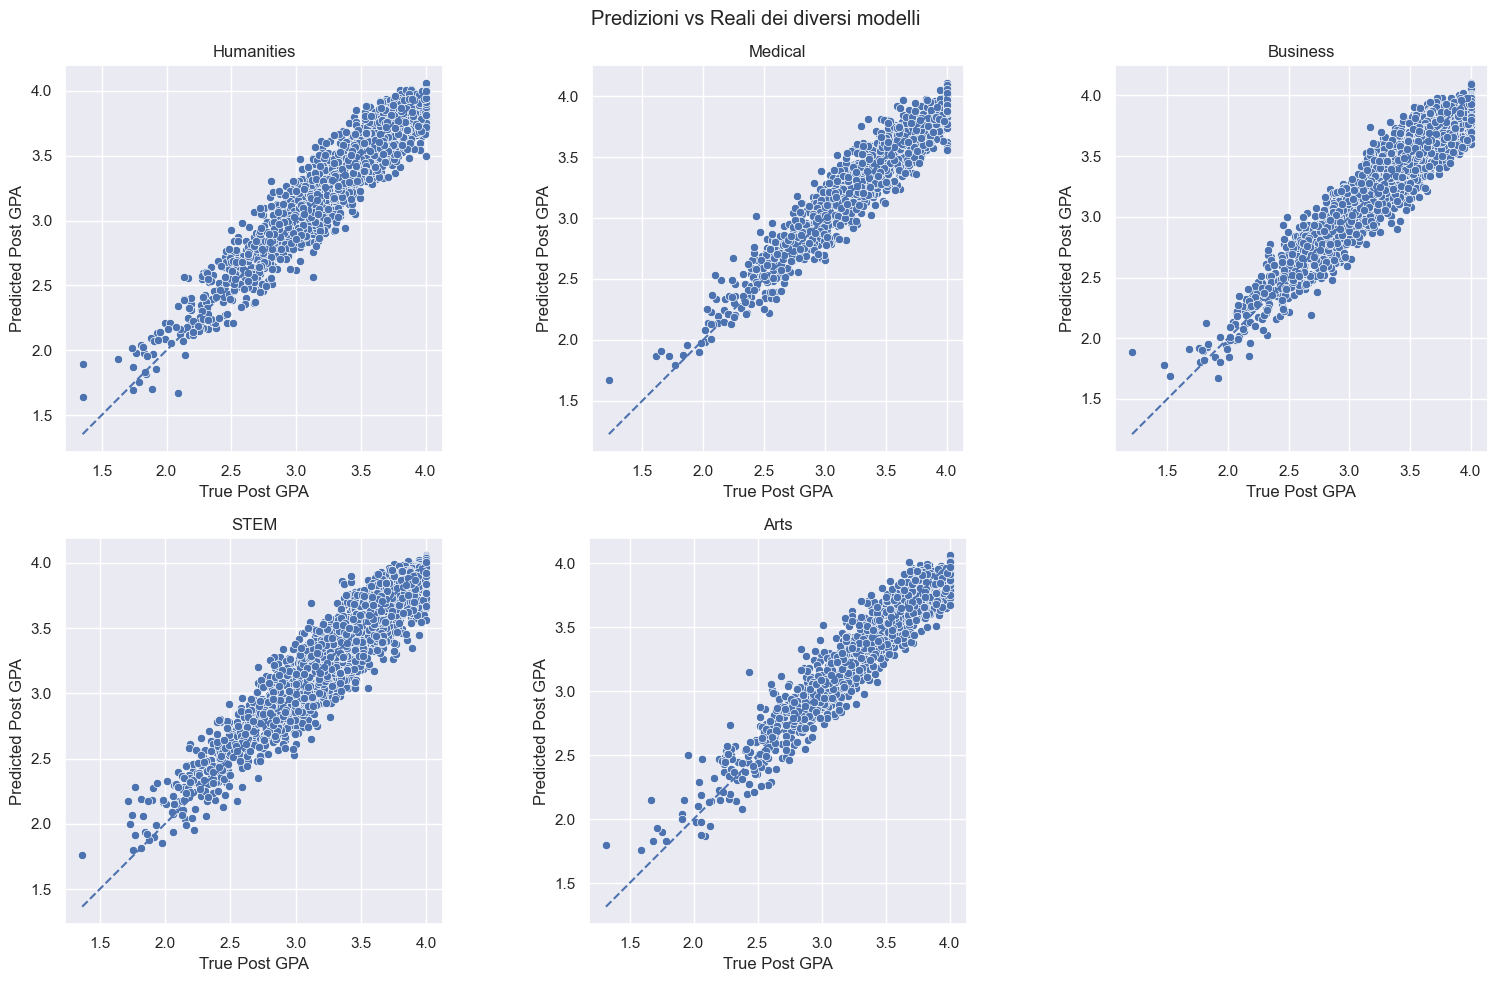

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
sns.set_theme(style='darkgrid')

for i, corso in enumerate(df_dict):
    optimal_params = model_params_major_dict[corso]

    model = XGBRegressor(**optimal_params)

    data = df_dict[corso]

    y = data["Post_Semester_GPA"]
    X = data.drop(columns="Post_Semester_GPA")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    print(f"{corso} mae:", mean_absolute_error(y_test, preds))
    print(f"{corso} r2:", r2_score(y_test, preds))

    sns.scatterplot(
        x=y_test,
        y=preds,
        ax=axes[i]
    )

    axes[i].set_title(corso)
    axes[i].set_xlabel("True Post GPA")
    axes[i].set_ylabel("Predicted Post GPA")
    axes[i].set_aspect('equal', adjustable='box')
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--',)

    

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Predizioni vs Reali dei diversi modelli")
plt.tight_layout()
plt.show()